Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipykernel_2532/3364253585.py:24: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
  df_survey = pd.read_csv(caminho_base + 'survey_results_public.csv')


✅ Sucesso: Bases carregadas diretamente do Google Drive!


/tmp/ipykernel_2532/3364253585.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Country', y='ConvertedCompYearly',


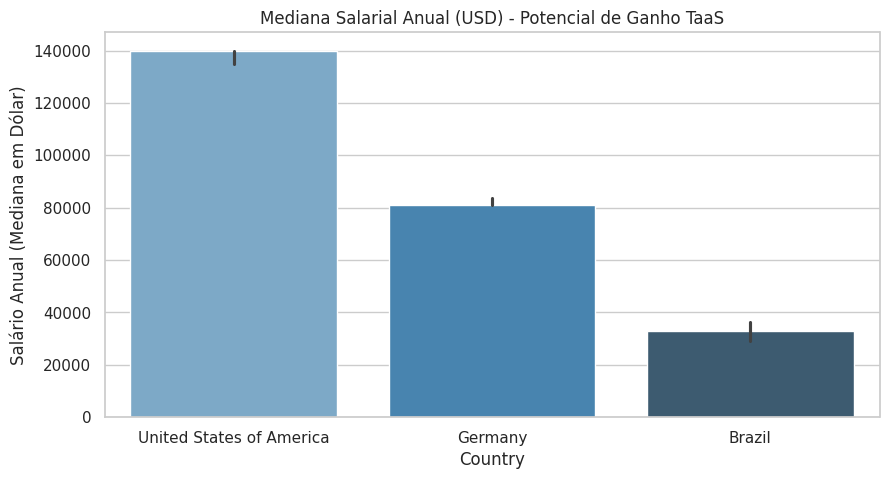

/tmp/ipykernel_2532/3364253585.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10_skills.values, y=top_10_skills.index, palette='viridis')


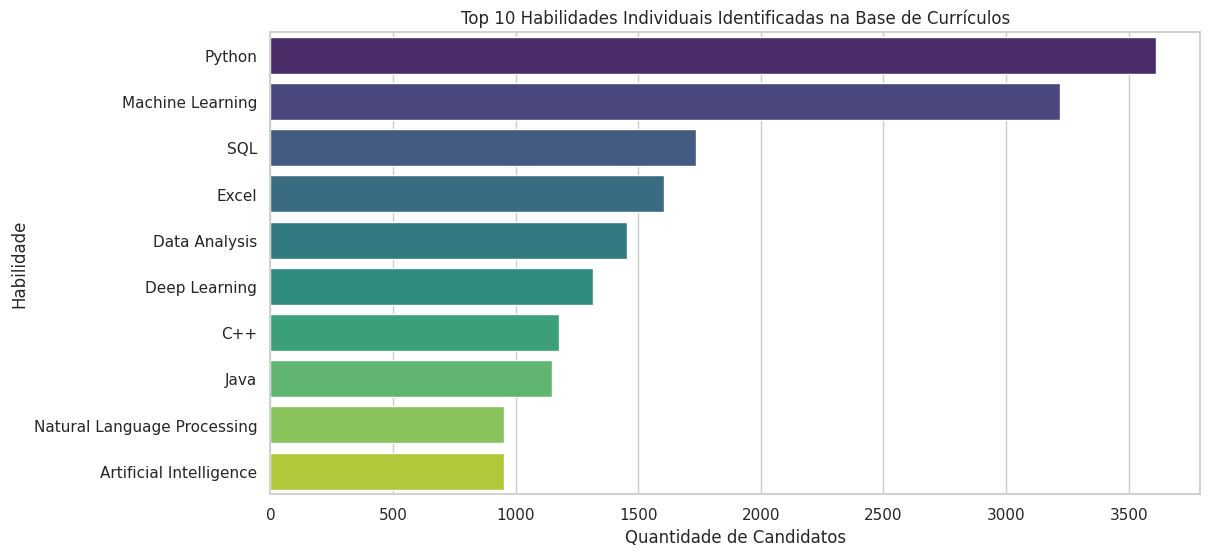

In [10]:
# ==============================================================================
# PROJETO INTERDISCIPLINAR - 4ADS - FECAP 2026
# Startup: Global Talent Bridge Ltda
# Disciplina: Ciência de Dados e Big Data
# ==============================================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
import os

# 1. MONTAGEM DO GOOGLE DRIVE
# É necessário autorizar o acesso ao Drive para executar a célula abaixo (pode permitir tudo).
drive.mount('/content/drive')

# 2. DEFINIÇÃO DO CAMINHO
caminho_base = '/content/drive/My Drive/FECAP/Savino/Entrega1_ADS4/Bases/'

# 3. CARREGAMENTO DAS BASES COM TRATAMENTO DE ERRO
try:
    df_resumes = pd.read_csv(caminho_base + 'resume_data.csv')
    df_postings = pd.read_csv(caminho_base + 'postings.csv')
    df_survey = pd.read_csv(caminho_base + 'survey_results_public.csv')
    print("✅ Sucesso: Bases carregadas diretamente do Google Drive!")
except FileNotFoundError:
    print("\n" + "=" * 60)
    print("⚠️  ATENÇÃO PROFESSOR ⚠️")
    print(f"Não foi possível localizar os arquivos em: {caminho_base}")
    print("\nPara que o código funcione, as bases .csv devem estar na pasta")
    print("mencionada acima dentro do seu Google Drive.")
    print("=" * 60)

# Configurações visuais globais para os gráficos
sns.set_theme(style="whitegrid")

# --- ANÁLISE 1: IMPACTO ECONÔMICO (SALÁRIOS) ---
# Limpeza de outliers (valores irreais) para garantir escala estatística legível
df_clean_salaries = df_survey[(df_survey['ConvertedCompYearly'] > 5000) &
                              (df_survey['ConvertedCompYearly'] < 250000)]

plt.figure(figsize=(10, 5))
sns.barplot(x='Country', y='ConvertedCompYearly',
            data=df_clean_salaries[df_clean_salaries['Country'].isin(['Brazil', 'United States of America', 'Germany'])],
            estimator='median', palette='Blues_d')
plt.title('Mediana Salarial Anual (USD) - Potencial de Ganho TaaS')
plt.ylabel('Salário Anual (Mediana em Dólar)')
plt.show()

# --- ANÁLISE 2: IMPACTO SOCIAL (DECOMPOSIÇÃO DINÂMICA DE SKILLS) ---
# 1. Limpeza: Remove colchetes e aspas da string original e separa por vírgula
skills_series = df_resumes['skills'].dropna().str.replace(r'[\[\]\']', '', regex=True).str.split(',')

# 2. Explode: Transforma listas em linhas individuais para contagem real
skills_individuais = skills_series.explode().str.strip()

# 3. Filtro: Remove entradas vazias geradas no processo de separação
skills_individuais = skills_individuais[skills_individuais != ""]

# 4. Cálculo do Top 10 real
top_10_skills = skills_individuais.value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_skills.values, y=top_10_skills.index, palette='viridis')
plt.title('Top 10 Habilidades Individuais Identificadas na Base de Currículos')
plt.xlabel('Quantidade de Candidatos')
plt.ylabel('Habilidade')
plt.show()